# Amenity Accessibility for All Categories

This section outlines the tasks involved in analyzing and documenting amenity accessibility. The first step is to view the available amenities, which provides an overview of the facilities and services in the area. Next, the planning area is examined to understand the broader geographical context. Following this, the subzone area is reviewed to focus on more localized regions. Finally, the amenity density scoring process is carried out to evaluate and quantify the accessibility of amenities within the specified areas.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point, Polygon
import math
import warnings
from scipy.spatial import cKDTree

warnings.filterwarnings('ignore')

# Install H3 if not already installed: pip install h3
try:
    import h3
    H3_AVAILABLE = True
except ImportError:
    H3_AVAILABLE = False
    print("⚠️ H3 library not found. Install with: pip install h3")
    print("   Falling back to manual hexagon creation")

# ===============================================================
# LOAD DATA
# ===============================================================

def load_and_prepare_singapore_data():
    """Load all_amenities_with_importance_score.geojson and planning areas"""
    print("=== Loading Singapore Amenities GeoJSON Data ===")

    # Load GeoJSON directly
    amenities = gpd.read_file("geojson/amenities_with_importance_score.geojson")
    amenities = amenities.to_crs("EPSG:3414")

    # Load planning area
    planning_area = gpd.read_file("geojson/planning_area.geojson").to_crs("EPSG:3414")

    print(f"✅ Loaded {len(amenities)} amenities with importance scores (GeoJSON)")
    print(f"✅ Categories: {amenities['amenity_category'].nunique()} | "
          f"{amenities['amenity_category'].unique()}")
    print(f"Importance score range: {amenities['importance_score'].min()} – {amenities['importance_score'].max()}")

    return amenities, planning_area

# ===============================================================
# HEXAGON GRID
# ===============================================================

def create_h3_hexagon_grid(boundary_gdf, resolution=8):
    """Create tessellated hexagon grid using H3"""
    print(f"Creating H3 hexagon grid (resolution={resolution})...")
    boundary_latlon = boundary_gdf.to_crs("EPSG:4326")
    hexagons = []
    hex_id = 0
    all_hex_ids = set()

    for geom in boundary_latlon.geometry:
        try:
            if hasattr(h3, 'polygon_to_cells'):  # H3 v4 API
                hex_ids = h3.polygon_to_cells(geom.__geo_interface__, resolution)
                all_hex_ids.update(hex_ids)
            else:  # H3 v3 API
                if geom.geom_type == "Polygon":
                    hex_ids = h3.polyfill(geom.__geo_interface__, resolution)
                    all_hex_ids.update(hex_ids)
                elif geom.geom_type == "MultiPolygon":
                    for poly in geom.geoms:
                        hex_ids = h3.polyfill(poly.__geo_interface__, resolution)
                        all_hex_ids.update(hex_ids)
        except Exception as e:
            print(f"H3 error while polyfilling: {e}")
            return create_manual_hexagon_grid(boundary_gdf, target_hexagons=3000)

    print(f"Found {len(all_hex_ids)} H3 hexagons covering Singapore")

    for h3_id in all_hex_ids:
        try:
            if hasattr(h3, "cell_to_boundary"):  # v4
                hex_boundary = h3.cell_to_boundary(h3_id, geo_json=True)
            else:  # v3
                hex_boundary = h3.h3_to_geo_boundary(h3_id, geo_json=True)

            hex_boundary = [(lon, lat) for lat, lon in hex_boundary]  # flip
            hex_polygon = Polygon(hex_boundary)

            if boundary_latlon.intersects(hex_polygon).any():
                hexagons.append({
                    "fid": hex_id,
                    "h3_id": h3_id,
                    "geometry": hex_polygon,
                    "demand": 100
                })
                hex_id += 1

        except Exception as e:
            print(f"Error processing H3 cell {h3_id}: {e}")
            continue

    if not hexagons:
        print("⚠️ No valid H3 hexagons, falling back to manual grid...")
        return create_manual_hexagon_grid(boundary_gdf, target_hexagons=3000)

    hex_gdf = gpd.GeoDataFrame(hexagons, crs="EPSG:4326").to_crs("EPSG:3414")
    print(f"✅ Created {len(hex_gdf)} H3 hexagons")
    return hex_gdf

def create_manual_hexagon_grid(boundary_gdf, target_hexagons=3000):
    """Fallback manual hexagon creation if H3 not available"""
    print(f"Creating manual hexagon grid targeting ~{target_hexagons} hexagons...")
    bounds = boundary_gdf.total_bounds
    total_area = (bounds[2] - bounds[0]) * (bounds[3] - bounds[1])
    hex_area = total_area / (target_hexagons * 1.2)
    hex_radius = math.sqrt(hex_area / (3 * math.sqrt(3) / 2))
    print(f"Calculated hex radius: {hex_radius:.0f}m")

    def create_pointy_top_hexagon(cx, cy, radius):
        vertices = []
        for i in range(6):
            angle = (i * math.pi / 3) + (math.pi / 6)
            x = cx + radius * math.cos(angle)
            y = cy + radius * math.sin(angle)
            vertices.append((x, y))
        return Polygon(vertices)

    hexagons = []
    hex_id = 0
    width = hex_radius * math.sqrt(3)
    height = hex_radius * 1.5
    y = bounds[1]
    row = 0
    while y < bounds[3]:
        x = bounds[0]
        if row % 2 == 1:
            x += width / 2
        while x < bounds[2]:
            hex_geom = create_pointy_top_hexagon(x, y, hex_radius)
            if boundary_gdf.geometry.intersects(hex_geom).any():
                hexagons.append({"fid": hex_id, "geometry": hex_geom, "demand": 100})
                hex_id += 1
            x += width
        y += height
        row += 1

    hexagons_gdf = gpd.GeoDataFrame(hexagons, crs=boundary_gdf.crs)
    print(f"✅ Created {len(hexagons_gdf)} manual hexagons")
    return hexagons_gdf

# ===============================================================
# ACCESSIBILITY
# ===============================================================

def calculate_distances(hexagons, amenities, k=20):
    """Efficient nearest-neighbour distance matrix using KDTree"""
    print("Calculating distance matrix with KDTree...")

    # Hexagon centroids
    centroids = np.array([[p.x, p.y] for p in hexagons.geometry.centroid])

    # Ensure amenities are represented as points
    amenity_points = amenities.geometry.apply(
        lambda g: g if isinstance(g, Point) else g.representative_point()
    )
    amenity_coords = np.array([[p.x, p.y] for p in amenity_points])

    tree = cKDTree(amenity_coords)
    k = min(k, len(amenities))  # cap k
    dists, idxs = tree.query(centroids, k=k)

    if k == 1:
        dists = dists[:, np.newaxis]
        idxs = idxs[:, np.newaxis]

    print(f"Distance range: {dists.min()/1000:.2f}km – {dists.max()/1000:.2f}km")
    return dists / 1000, idxs


def calculate_hansen_accessibility(hexagons, amenities, dists_km, idxs, power=2):
    """Hansen accessibility using nearest-neighbour distances, safe against empty/NaN"""
    print(f"Calculating Hansen accessibility (power={power})...")

    if len(amenities) == 0:
        # No amenities in this category
        accessibility = np.zeros(len(hexagons))
        print("⚠️ No amenities found → all accessibility = 0")
        return accessibility

    capacity = amenities["importance_score"].values
    demand = hexagons["demand"].values
    accessibility = np.zeros(len(demand))

    for i in range(len(demand)):
        chosen_capacities = capacity[idxs[i]]
        chosen_distances = dists_km[i]

        mask = np.isfinite(chosen_distances) & (chosen_distances > 0)
        if not np.any(mask):
            accessibility[i] = 0.0
        else:
            accessibility[i] = np.sum(
                chosen_capacities[mask] / (chosen_distances[mask] ** power + 0.01)
            )

    if len(accessibility) > 0:
        print(
            f"Accessibility range: {np.nanmin(accessibility):.2f} – {np.nanmax(accessibility):.2f}, "
            f"Mean={np.nanmean(accessibility):.2f}"
        )
    else:
        print("⚠️ Accessibility array empty")

    return accessibility

# ===============================================================
# MAIN RUNNER
# ===============================================================

def run_complete_amenity_accessibility_analysis(resolution=8, category=None):
    """Run accessibility analysis for one category, return GeoDataFrame only"""
    amenities, planning_area = load_and_prepare_singapore_data()

    if category:
        amenities = amenities[amenities["amenity_category"] == category]
        if len(amenities) == 0:
            return gpd.GeoDataFrame(), amenities, None, None  # return empty if nothing

    # make hex grid
    if H3_AVAILABLE:
        hexagons = create_h3_hexagon_grid(planning_area, resolution=resolution)
    else:
        hexagons = create_manual_hexagon_grid(planning_area, target_hexagons=3000)

    # distances + accessibility
    dists_km, idxs = calculate_distances(hexagons, amenities, k=20)
    accessibility = calculate_hansen_accessibility(hexagons, amenities, dists_km, idxs)

    hexagons["accHansen"] = accessibility
    return hexagons, amenities, accessibility, dists_km

# ===============================================================
# MULTI-CATEGORY VISUALIZATION
# ===============================================================

def analyze_all_categories_by_region_map(categories,
                                         resolution=8,
                                         planning_area_path="./geojson/planning_area.geojson",
                                         cmap="cividis"):
    """Run for all categories → return one consolidated figure + summary table"""
    planning_area = gpd.read_file(planning_area_path).to_crs("EPSG:3414")
    all_hexagons = []
    summary_stats = []

    # ========== RUN ANALYSIS WITHOUT INTERMEDIATE PRINTS ==========
    for cat in categories:
        hexagons_with_acc, amenities, _, _ = run_complete_amenity_accessibility_analysis(
            resolution=resolution, category=cat
        )
        if hexagons_with_acc.empty:
            continue  # skip if no amenities

        hexagon_with_regions = gpd.sjoin(
            hexagons_with_acc,
            planning_area,
            how="left",
            predicate="intersects"
        )
        hexagon_with_regions["category"] = cat
        all_hexagons.append((cat, hexagon_with_regions, amenities))

        # collect summary stats
        acc = hexagons_with_acc["accHansen"].replace([np.inf, -np.inf], np.nan).fillna(0)
        summary_stats.append({
            "Category": cat,
            "Min": acc.min(),
            "Max": acc.max(),
            "Mean": acc.mean()
        })

    # ========== ONE CONSOLIDATED MULTI-PANEL PLOT ==========
    fig, axes = plt.subplots(5, 2, figsize=(18, 25))
    axes = axes.flatten()

    for idx, (cat, hexagons, amenities) in enumerate(all_hexagons):
        ax = axes[idx]
        hexagons.plot(
            column="accHansen",
            cmap=cmap,
            scheme="quantiles",
            k=10,
            legend=False,
            ax=ax,
            edgecolor="white",
            linewidth=0.05
        )
        amenities.plot(ax=ax, markersize=1, alpha=0.2, marker=".", color="red")
        ax.set_title(f"Accessibility to {cat.replace('_',' ').title()}",
                     fontsize=14, fontweight="bold")
        ax.axis("off")

    # hide extra panels
    for j in range(len(all_hexagons), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    # ========== CONSOLIDATED SUMMARY ==========
    print("\n" + "=" * 60)
    print("CONSOLIDATED ANALYSIS COMPLETE")
    print(f"Categories analysed: {', '.join([c for c,_,_ in all_hexagons])}")
    print("=" * 60)

    summary_df = pd.DataFrame(summary_stats)
    print(summary_df.to_string(index=False, float_format="%.2f"))

    return all_hexagons, summary_df

=== Loading Singapore Amenities GeoJSON Data ===
✅ Loaded 37726 amenities with importance scores (GeoJSON)
✅ Categories: 10 | ['transport_services' 'essential_services' 'community_spaces'
 'government_services' 'emergency_services' 'residential'
 'retail_services' 'education_institutions' 'tourism' 'others']
Importance score range: 0.2 – 25.0
Creating H3 hexagon grid (resolution=8)...
H3 error while polyfilling: Unrecognized type: <class 'dict'>
Creating manual hexagon grid targeting ~3000 hexagons...
Calculated hex radius: 445m
✅ Created 1845 manual hexagons
Calculating distance matrix with KDTree...
Distance range: 0.01km – 14.44km
Calculating Hansen accessibility (power=2)...
Accessibility range: 0.81 – 5086.24, Mean=562.32
=== Loading Singapore Amenities GeoJSON Data ===
✅ Loaded 37726 amenities with importance scores (GeoJSON)
✅ Categories: 10 | ['transport_services' 'essential_services' 'community_spaces'
 'government_services' 'emergency_services' 'residential'
 'retail_services

ValueError: zero-size array to reduction operation minimum which has no identity

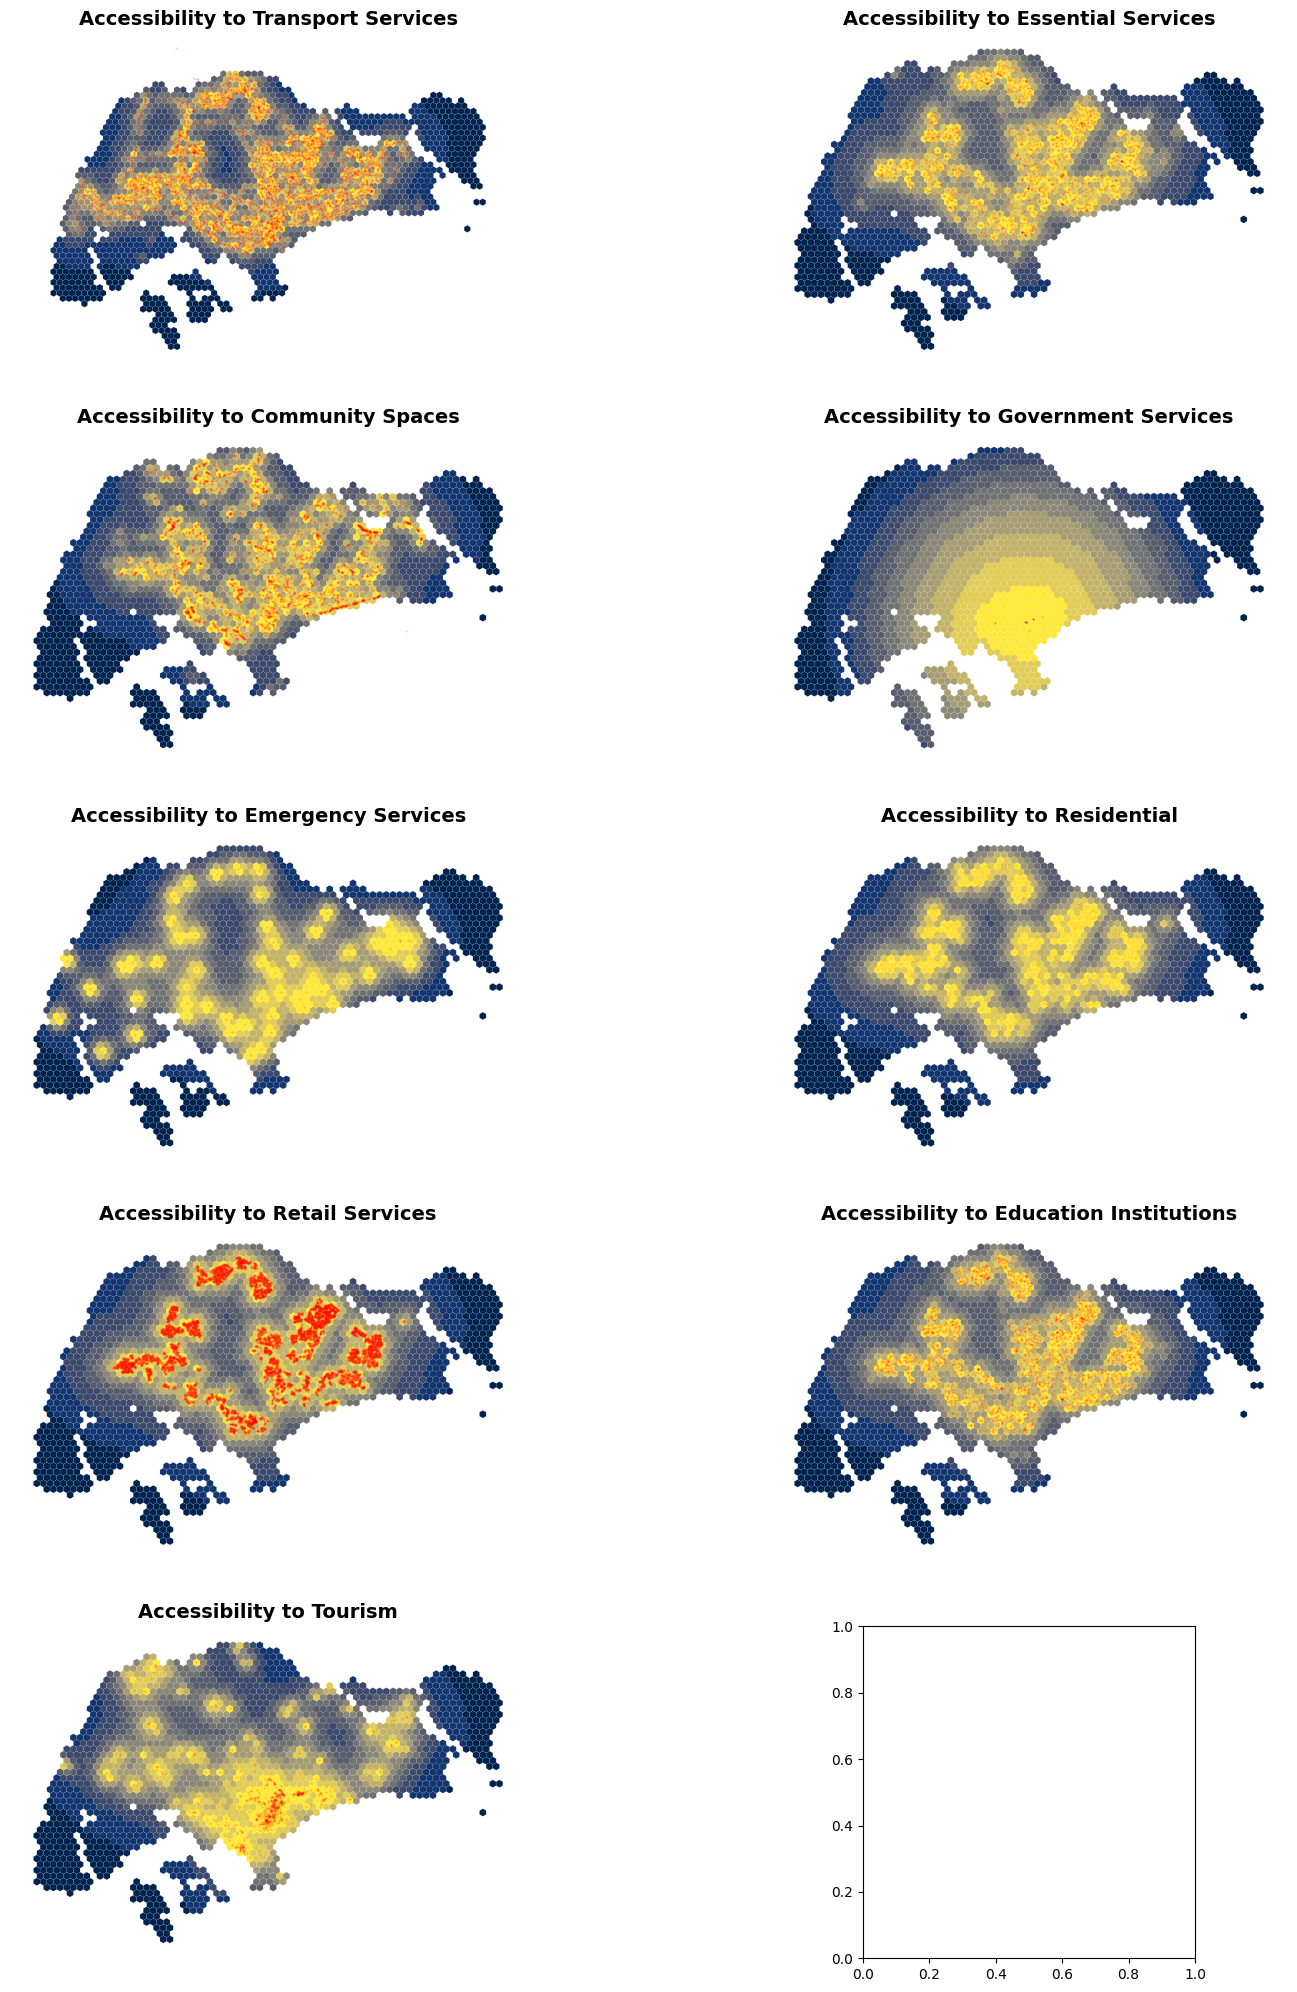

In [2]:
categories = [
    "transport_services", "essential_services", "community_spaces",
    "government_services", "emergency_services", "residential",
    "retail_services", "education_institutions", "tourism", "others"
]


all_results, summary_df = analyze_all_categories_by_region_map(categories, resolution=8)

In [ ]:
def run_accessibility_for_woodlands_subzones(category=None,
                                             resolution=8,
                                             amenities_path="./geojson/amenities_with_importance_score.geojson",
                                             subzone_path="./geojson/subzone_area.geojson",
                                             cmap="cividis",
                                             metric="hansen"):
    """
    Run accessibility analysis for Woodlands subzones.
    metric = "hansen" → Hansen accessibility (capacity/distance^2)
    metric = "distance" → Mean nearest-neighbour distance
    Returns:
      - GeoDataFrame of hexagons tagged with subzones
      - DataFrame of summary stats per subzone
    """
    # Load data
    amenities = gpd.read_file(amenities_path).to_crs("EPSG:3414")
    subzones = gpd.read_file(subzone_path).to_crs("EPSG:3414")

    # Filter to Woodlands subzones only
    woodlands_subzones = subzones[subzones["PLN_AREA_N"].str.contains("Woodlands", case=False)]
    if woodlands_subzones.empty:
        raise ValueError("No subzones found for Woodlands in the dataset.")

    # Filter amenities by category
    if category:
        amenities = amenities[amenities["amenity_category"] == category]
        print(f"⚡ Category={category} | {len(amenities)} amenities in Singapore")
        if amenities.empty:
            print("⚠️ No amenities found for this category. Accessibility = 0 everywhere.")

    # Clip amenities to Woodlands extent for plotting
    amenities_clipped = gpd.clip(amenities, woodlands_subzones)

    # Generate hexagons covering Woodlands
    if H3_AVAILABLE:
        hexagons = create_h3_hexagon_grid(woodlands_subzones, resolution=resolution)
    else:
        hexagons = create_manual_hexagon_grid(woodlands_subzones, target_hexagons=1500)

    # Distances
    dists_km, idxs = calculate_distances(hexagons, amenities, k=20)

    if metric == "hansen":
        accessibility = calculate_hansen_accessibility(hexagons, amenities, dists_km, idxs)
    elif metric == "distance":
        accessibility = np.nanmean(dists_km, axis=1)  # average distance to k nearest amenities
    else:
        raise ValueError("metric must be 'hansen' or 'distance'")

    hexagons["accessibility"] = accessibility
    hexagons_with_subzones = gpd.sjoin(
        hexagons,
        woodlands_subzones[["SUBZONE_N", "geometry"]],
        how="left",
        predicate="intersects"
    )

    # Summary stats by subzone
    summary = (
        hexagons_with_subzones.groupby("SUBZONE_N")["accessibility"]
        .agg(["min", "max", "mean"])
        .reset_index()
    )

    # Plot Woodlands accessibility
    fig, ax = plt.subplots(figsize=(12, 10))
    hexagons_with_subzones.plot(
        column="accessibility",
        cmap=cmap,
        scheme="quantiles",
        k=10,
        legend=True,
        edgecolor="white",
        linewidth=0.05,
        ax=ax
    )
    amenities_clipped.plot(ax=ax, markersize=15, color="red", alpha=0.7, label="Amenities")
    woodlands_subzones.boundary.plot(ax=ax, color="black", linewidth=0.8)

    # Zoom into Woodlands
    xmin, ymin, xmax, ymax = woodlands_subzones.total_bounds
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_title(
        f"Accessibility in Woodlands Subzones ({category.replace('_',' ').title() if category else 'All Amenities'})",
        fontsize=15, fontweight="bold"
    )
    ax.axis("off")
    ax.legend()

    plt.tight_layout()
    plt.show()

    return hexagons_with_subzones, summary


⚡ Category=education_institutions | 2270 amenities in Singapore
Creating H3 hexagon grid (resolution=8)...
H3 error while polyfilling: Unrecognized type: <class 'dict'>
Creating manual hexagon grid targeting ~3000 hexagons...
Calculated hex radius: 50m
✅ Created 2196 manual hexagons
Calculating distance matrix with KDTree...
Distance range: 0.00km – 2.43km
Calculating Hansen accessibility (power=2)...
Accessibility range: 41.06 – 5918.70, Mean=895.69


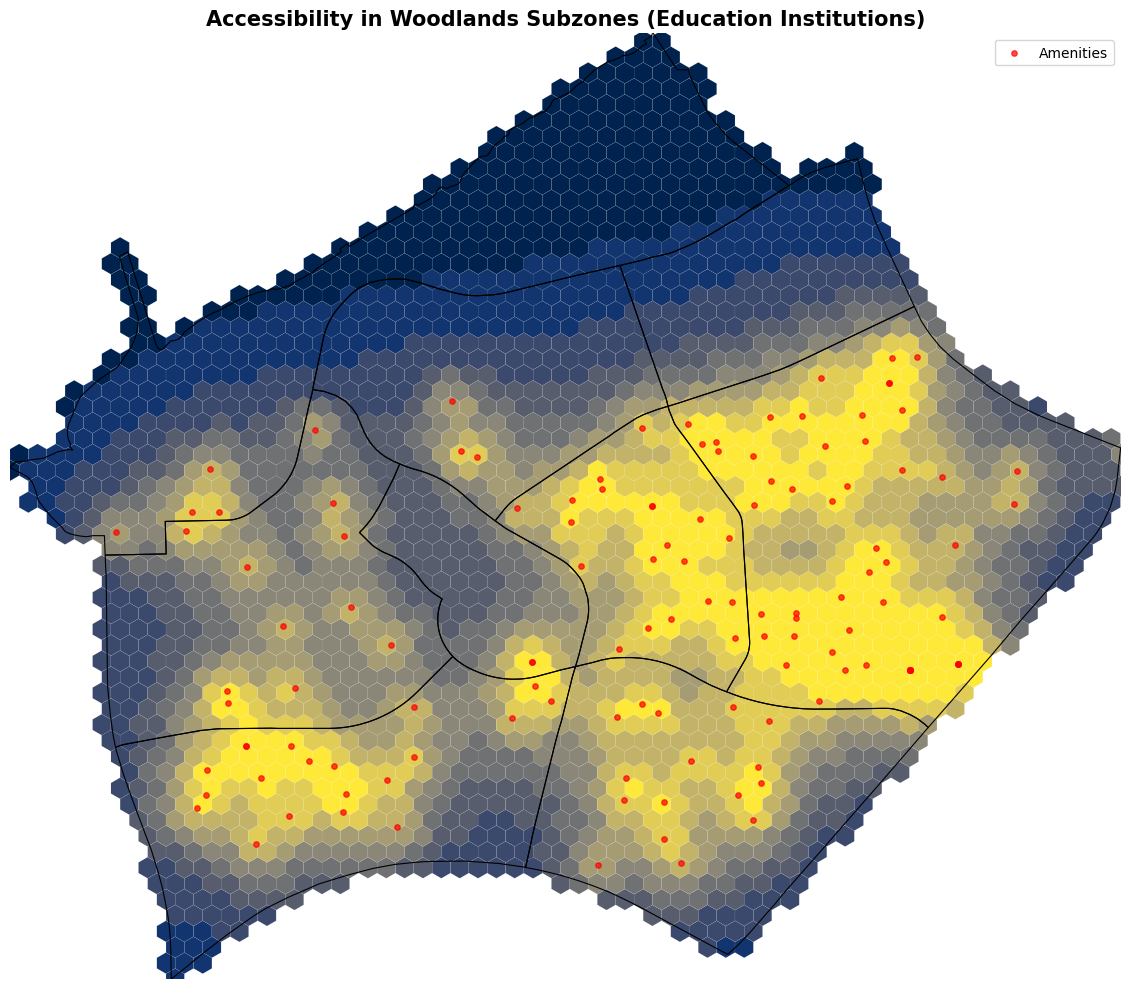

        SUBZONE_N         min          max         mean
0  GREENWOOD PARK  112.099194  1667.758451   473.414734
1         MIDVIEW  803.547021  2739.024611  1681.406513
2     NORTH COAST   41.062279  1859.012611   233.602839
3     SENOKO WEST   94.827895  1440.131596   358.014719
4       WOODGROVE  126.981624  2610.305093  1009.208937
⚡ Category=transport_services | 5407 amenities in Singapore
Creating H3 hexagon grid (resolution=8)...
H3 error while polyfilling: Unrecognized type: <class 'dict'>
Creating manual hexagon grid targeting ~3000 hexagons...
Calculated hex radius: 50m
✅ Created 2196 manual hexagons
Calculating distance matrix with KDTree...
Distance range: 0.00km – 1.67km
Calculating Hansen accessibility (power=2)...
Accessibility range: 114.23 – 4712.84, Mean=1358.91


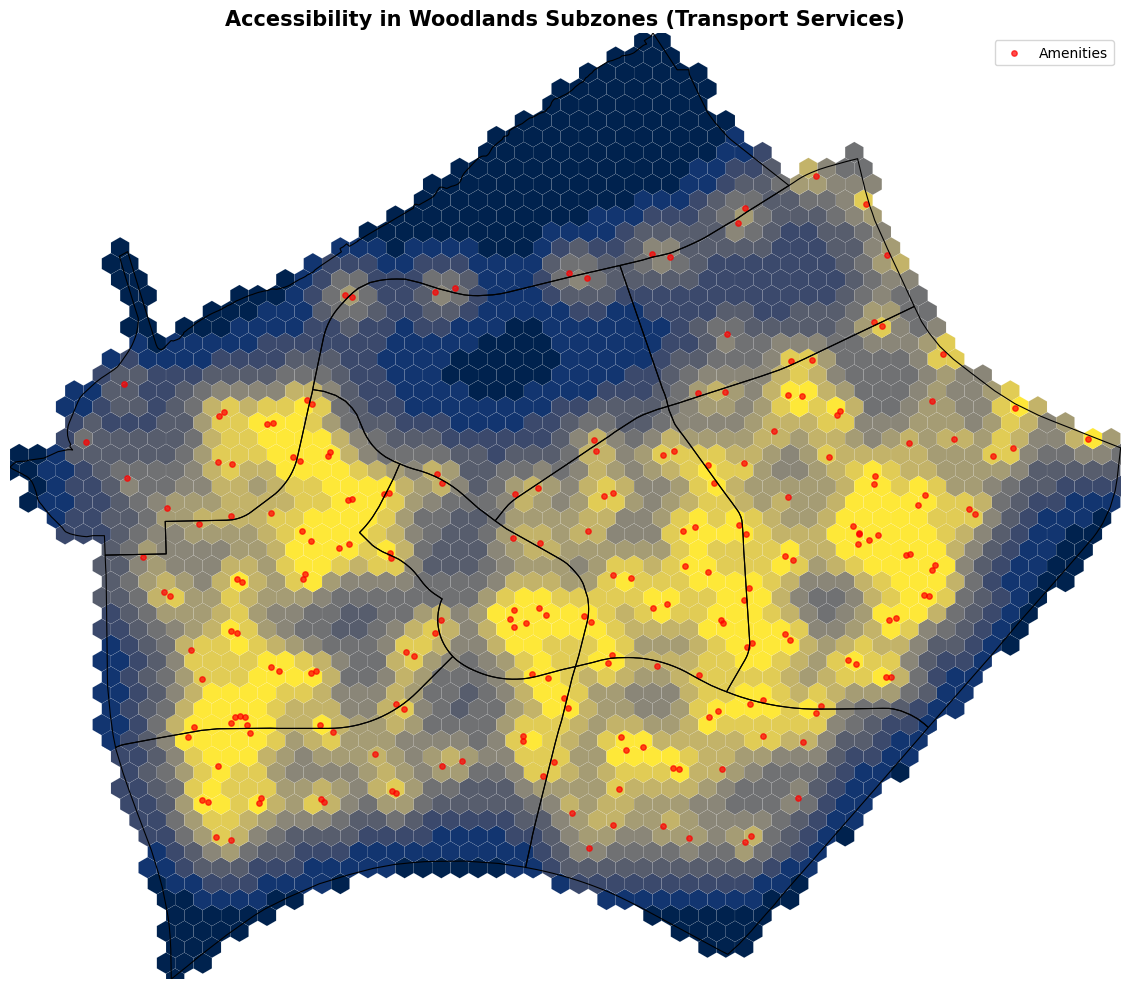

        SUBZONE_N         min          max         mean
0  GREENWOOD PARK  369.716753  2077.545550   819.987960
1         MIDVIEW  946.447284  3186.949382  2062.335467
2     NORTH COAST  114.229494  3141.687337   776.559743
3     SENOKO WEST  552.024059  2215.533996  1123.720379
4       WOODGROVE  161.526585  4712.841522  1352.551358


In [ ]:
# Try with 3 categories
cats = ["education_institutions", "transport_services"]

for c in cats:
    hex_subzones, summary = run_accessibility_for_woodlands_subzones(category=c)
    print(summary.head())
